#Minería de datos y modelización predictiva - Práctica final





#Competición Fuga de Clientes - Grupo ONU

Autores: Silvia Maribel Álvarez Betancourt, Olivier Cyril Leonard Antonini, Jervin Grace Apostol, Andrea Paola Fajardo Linares, Diana Alejandra Merma Revilla, Delia Rabanal González y Patricia Villaverde Cano

##1) Lectura e inspección de datos.

- Vinculamos a Drive, importamos librerías y cargamos datos

In [1]:
import importlib.util

required = ["numpy", "pandas", "matplotlib", "seaborn", "plotly", "scipy", "statsmodels", "sklearn"]
for pkg in required:
    spec = importlib.util.find_spec(pkg)
    print(f"{pkg}: {'OK' if spec else 'MISSING'}")

numpy: OK
pandas: OK
matplotlib: OK
seaborn: OK
plotly: OK
scipy: OK
statsmodels: MISSING
sklearn: MISSING


In [6]:
pip install "C:\Users\eezi01\Downloads\scikit_learn-1.8.0-cp312-cp312-win_amd64.whl"


Defaulting to user installation because normal site-packages is not writeable
Processing c:\users\eezi01\downloads\scikit_learn-1.8.0-cp312-cp312-win_amd64.whl
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install "C:\Users\eezi01\Downloads\joblib-1.5.3-py3-none-any.whl"


Defaulting to user installation because normal site-packages is not writeable
Processing c:\users\eezi01\downloads\joblib-1.5.3-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install "C:\Users\eezi01\Downloads\threadpoolctl-3.6.0-py3-none-any.whl"

Defaulting to user installation because normal site-packages is not writeable
Processing c:\users\eezi01\downloads\threadpoolctl-3.6.0-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install "C:\Users\eezi01\Downloads\scipy-1.17.1-cp312-cp312-win_amd64.whl"


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (4273167815.py, line 1)

In [7]:
pip install "C:\Users\eezi01\Downloads\statsmodels-0.14.6-cp312-cp312-win_amd64.whl"

Defaulting to user installation because normal site-packages is not writeable
Processing c:\users\eezi01\downloads\statsmodels-0.14.6-cp312-cp312-win_amd64.whl
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install "C:\Users\eezi01\Downloads\patsy-1.0.2-py2.py3-none-any.whl"

Defaulting to user installation because normal site-packages is not writeable
Processing c:\users\eezi01\downloads\patsy-1.0.2-py2.py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import logit

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LassoLarsIC
from sklearn import linear_model
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc



pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df= pd.read_csv('FugaClientes_Training.csv')

- Lectura de datos, distribución y verificación de variables

In [3]:
df.head()

,ID,Genero,Mayor65,Conyuge,PersCargo,Antig.fc.edad,Telf_serv,VariasLineas,Int_serv,Seguridad,CopiaSeguridad,Antivirus_disp,Soporte_tecnico,TV_streaming,Peliculas,Contrato,Fact_sinPapel,MetodoPago,FacturaMes,FacturaTotal,Fuga
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,NaN,NaN,29.85,0
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,NaN,1889.50,0
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,NaN,0.0,No,No,45.0,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,NaN,42.30,1840.75,0
4,9237-HQITU,Female,0.0,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
df.describe()

,Mayor65,Antig.fc.edad,FacturaMes,FacturaTotal,Fuga
count,6001.000000,5959.000000,5959.000000,6342.000000,6353.000000
mean,0.159307,32.380769,64.678369,2268.727152,0.265386
std,0.365992,24.540411,30.013422,2258.843022,0.441574
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.550000,394.475000,0.000000
50%,0.000000,29.000000,70.300000,1384.175000,0.000000
75%,0.000000,55.000000,89.800000,3781.512500,1.000000
max,1.000000,72.000000,118.750000,8672.450000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6353 entries, 0 to 6352
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               6353 non-null   str    
 1   Genero           6001 non-null   str    
 2   Mayor65          6001 non-null   float64
 3   Conyuge          6353 non-null   str    
 4   PersCargo        6353 non-null   str    
 5   Antig.fc.edad    5959 non-null   float64
 6   Telf_serv        6261 non-null   str    
 7   VariasLineas     6353 non-null   str    
 8   Int_serv         6163 non-null   str    
 9   Seguridad        6353 non-null   str    
 10  CopiaSeguridad   6353 non-null   str    
 11  Antivirus_disp   6353 non-null   str    
 12  Soporte_tecnico  6353 non-null   str    
 13  TV_streaming     6353 non-null   str    
 14  Peliculas        6353 non-null   str    
 15  Contrato         5959 non-null   str    
 16  Fact_sinPapel    6092 non-null   str    
 17  MetodoPago       5881 non

- Verificamos la proporción de evento.

In [6]:
df['Fuga'].value_counts(normalize=True)

Fuga
0    0.734614
1    0.265386
Name: proportion, dtype: float64

- Se elimina a la variable ID y guardamos la variable binaria Fuga

In [7]:
varobj = df['Fuga']
df_tr = df.drop(columns = ['ID'])

- Missings

Faltan datos en las variables Genero, Mayores, Antig.fc.edad, Telf_serv, Int_serv, Contrato, Fact_sinPapel, MetodoPago, FacturaMes, FacturaTotal

In [8]:
missings = df.isna().sum()

missings = missings[missings > 0]

tabla_missings = pd.DataFrame({
    "Num_Missings": missings,
    "Porcentaje (%)": round(missings / len(df) * 100, 2)
}).sort_values("Num_Missings", ascending=False)

tabla_missings


,Num_Missings,Porcentaje (%)
MetodoPago,472,7.43
Antig.fc.edad,394,6.20
FacturaMes,394,6.20
Contrato,394,6.20
Mayor65,352,5.54
Genero,352,5.54
Fact_sinPapel,261,4.11
Int_serv,190,2.99
Telf_serv,92,1.45
FacturaTotal,11,0.17


- Atípicos: no se aprecia la presencia de atípicos en el conjunto de datos

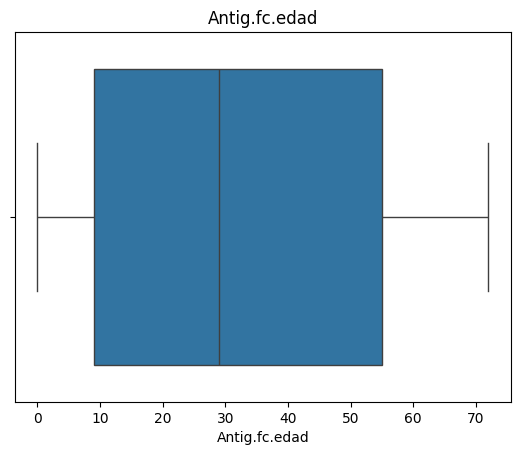

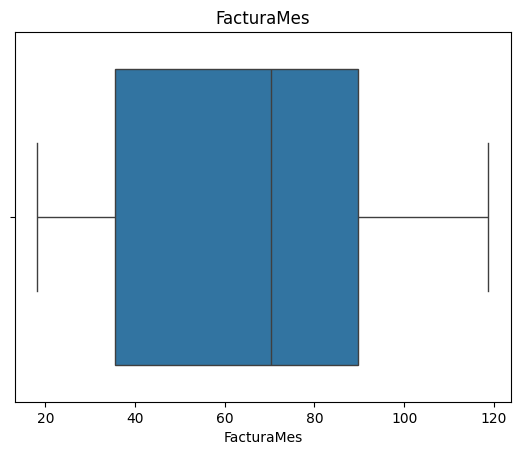

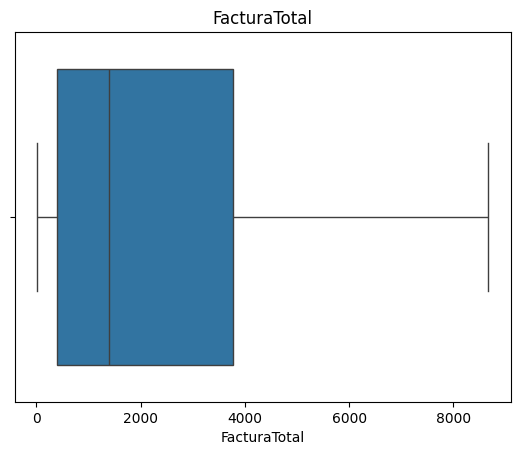

In [9]:
for col in ['Antig.fc.edad','FacturaMes','FacturaTotal']:
    sns.boxplot(x=df_tr[col])
    plt.title(col)
    plt.show()

##2) Depuración de los datos.

- Modificamos tipos de variables y la variable objetico Fuga.

In [10]:

categoricas = ['Genero',
               'Mayor65',
               'Conyuge',
               'PersCargo',
               'Telf_serv',
               'VariasLineas',
               'Int_serv',
               'Seguridad',
               'CopiaSeguridad',
               'Antivirus_disp',
               'Soporte_tecnico',
               'TV_streaming',
               'Peliculas',
               'Contrato',
               'Fact_sinPapel',
               'MetodoPago',
               'Fuga']

for col in categoricas:
    df[col] = df[col].astype('category')


# Verificación de la conversión de variables:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6353 entries, 0 to 6352
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               6353 non-null   str     
 1   Genero           6001 non-null   category
 2   Mayor65          6001 non-null   category
 3   Conyuge          6353 non-null   category
 4   PersCargo        6353 non-null   category
 5   Antig.fc.edad    5959 non-null   float64 
 6   Telf_serv        6261 non-null   category
 7   VariasLineas     6353 non-null   category
 8   Int_serv         6163 non-null   category
 9   Seguridad        6353 non-null   category
 10  CopiaSeguridad   6353 non-null   category
 11  Antivirus_disp   6353 non-null   category
 12  Soporte_tecnico  6353 non-null   category
 13  TV_streaming     6353 non-null   category
 14  Peliculas        6353 non-null   category
 15  Contrato         5959 non-null   category
 16  Fact_sinPapel    6092 non-null   category
 17  Metodo

In [11]:
varobj = df['Fuga']
df_tr = df.drop(columns = ['ID'])

- Tratamiento de missings.

Falta de información clave sobre el cliente, servicios o contrato se crea una categoria desconocida: "Desc".

Hay 10 variables con missings: Genero, Mayores, Antig.fc.edad, Telf_serv, Int_serv, Contrato, Fact_sinPapel, MetodoPago, FacturaMes, FacturaTotal

Primero se van a tratar las 7 cualitativas: Genero, Mayores, Telf_serv, Int_serv, Contrato, Fact_sinPapel, MetodoPago

In [12]:
def add_category_and_fill(df, col, fill_value="Desc"):

    # Añadir la categoría "Desc" si no existe
    if fill_value not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories([fill_value])

    # Rellenar valores faltantes con "Desc"
    df[col] = df[col].fillna(fill_value)

cols_to_fill_with_desc = [
    'Genero',
    'Mayor65',
    'Telf_serv',
    'Int_serv',
    'Contrato',
    'Fact_sinPapel',
    'MetodoPago'
]

for col in cols_to_fill_with_desc:
    add_category_and_fill(df_tr, col, "Desc")

servicio_extra = [
    'Telf_serv',
    'VariasLineas',
    'Seguridad',
    'CopiaSeguridad',
    'Antivirus_disp',
    'Soporte_tecnico',
    'TV_streaming',
    'Peliculas']

# Crear variable numérica (conteo de "Yes")
df_tr['Servicios_Extra'] = (df_tr[servicio_extra] == 'Yes').sum(axis=1)

# Convertir a categórica
df_tr['Servicios_Extra'] = df_tr['Servicios_Extra'].astype('category')

df_tr.head()


,Genero,Mayor65,Conyuge,PersCargo,Antig.fc.edad,Telf_serv,VariasLineas,Int_serv,Seguridad,CopiaSeguridad,Antivirus_disp,Soporte_tecnico,TV_streaming,Peliculas,Contrato,Fact_sinPapel,MetodoPago,FacturaMes,FacturaTotal,Fuga,Servicios_Extra
0,Female,0.0,Yes,No,1.0,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Desc,NaN,29.85,0,1
1,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,NaN,1889.50,0,3
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3
3,Desc,0.0,No,No,45.0,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Desc,42.30,1840.75,0,3
4,Female,0.0,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1


Limpiamos las 3 variables cuantitativas con missings: Antig.fc.edad, FacturaMes, FacturaTotal

In [13]:
#Antig.fc.edad: tiene una relacion significativa con la variable objetiva
Vcramer(varobj, df_tr['Antig.fc.edad'])

NameError: name 'Vcramer' is not defined

In [14]:
def cramers_v(x, y):
    """
    Calcula la V de Cramér entre dos variables categóricas
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Aplicar V de Cramér
varobj_cat = df_tr['Fuga'].astype('category')
Vcramer_result = cramers_v(df_tr['Antig.fc.edad'], varobj_cat)
print(f"V de Cramér: {Vcramer_result}")

V de Cramér: 0.39797737899858204


In [15]:
def recode(a):
  if pd.isna(a): return 'Desconocido'
  if a <= 6: return '0-6 meses'
  if a <= 12: return '6-12 meses'
  if a <= 30: return '12-30 meses'
  if a <= 55: return '30-55 meses'
  return 'Mas de 55 meses'

In [16]:
#aplicamos la media a los NAN (ya hemos guardado este datos en la columna creada arriba y discretizamos los datos)


df_tr['Antig.fc.edad2'] = df_tr['Antig.fc.edad'].apply(recode)
df_tr['Antig.fc.edad2'] = df_tr['Antig.fc.edad2'].astype('category')
df_tr['Antig.fc.edad2'].value_counts(dropna=False)
df_tr.head()

,Genero,Mayor65,Conyuge,PersCargo,Antig.fc.edad,Telf_serv,VariasLineas,Int_serv,Seguridad,CopiaSeguridad,Antivirus_disp,Soporte_tecnico,TV_streaming,Peliculas,Contrato,Fact_sinPapel,MetodoPago,FacturaMes,FacturaTotal,Fuga,Servicios_Extra,Antig.fc.edad2
0,Female,0.0,Yes,No,1.0,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Desc,NaN,29.85,0,1,0-6 meses
1,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,NaN,1889.50,0,3,30-55 meses
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3,0-6 meses
3,Desc,0.0,No,No,45.0,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Desc,42.30,1840.75,0,3,30-55 meses
4,Female,0.0,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,Desconocido


In [17]:
# 2. Factura mes

df_tr['FacturaMes'] = df_tr['FacturaMes'].fillna(df_tr['FacturaMes'].median())

In [18]:
# Factura Total

df_tr['FacturaTotal'] = df_tr['FacturaTotal'].fillna(df_tr['FacturaTotal'].median())

## 3) Estudio de variables y relaciones con la variable objetivo

- Etudiamos la relaciones de las variables categóricas con la variable objetivo Fuga

In [19]:
varObjBin = df_tr['Fuga'].astype('category')

inputCat = df_tr.drop(columns=['Fuga']).select_dtypes(include='category')

In [20]:
# Variables categóricas (sin Fuga)
inputCat = df_tr.drop(columns=['Fuga']).select_dtypes(include=['object','category'])

# Calcular V de Cramer
tablaCramer = pd.DataFrame(inputCat.apply(lambda x: cramers_v(x, varObjBin)),columns=['VCramer']).sort_values('VCramer', ascending=False)

In [22]:
# Definir la función cramers_v antes de usarla
def cramers_v(x, y):
    """
    Calcula la V de Cramér entre dos variables categóricas
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Aplicar V de Cramér a Antig.fc.edad
varobj_cat = df_tr['Fuga'].astype('category')
Vcramer_result = cramers_v(df_tr['Antig.fc.edad'], varobj_cat)
print(f"V de Cramér (Antig.fc.edad vs Fuga): {Vcramer_result:.4f}")

V de Cramér (Antig.fc.edad vs Fuga): 0.3980


- Etudiamos la relaciones de las variables continuas con la variable objetivo Fuga

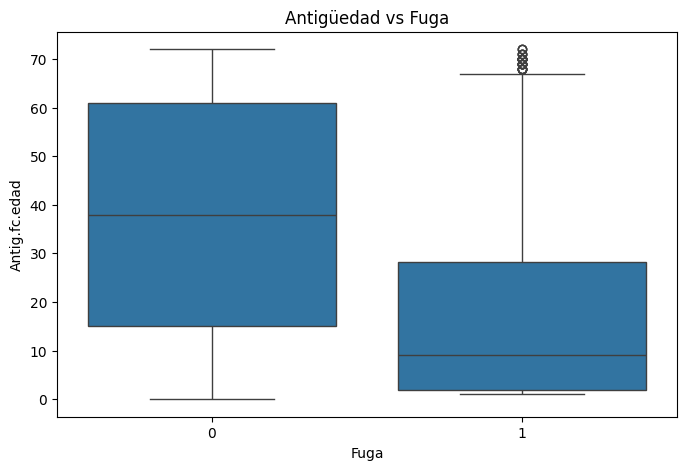

In [23]:
plt.rcParams["figure.figsize"] = (8,5)
plt.clf()
sns.boxplot(x='Fuga', y='Antig.fc.edad', data=df_tr)
plt.title('Antigüedad vs Fuga')
plt.show()

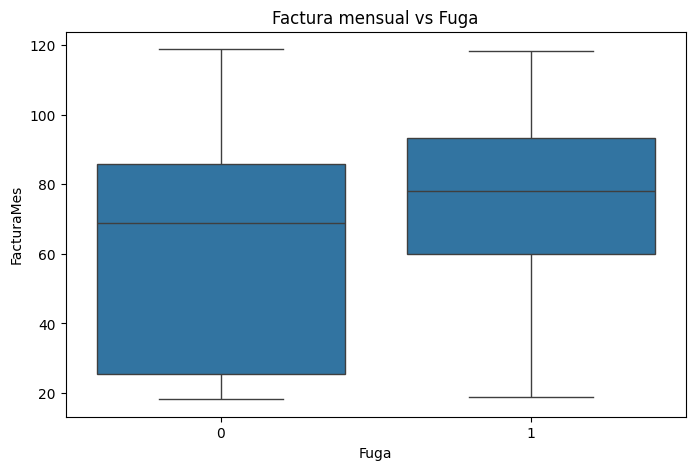

In [24]:
plt.clf()
sns.boxplot(x='Fuga', y='FacturaMes', data=df_tr)
plt.title('Factura mensual vs Fuga')
plt.show()


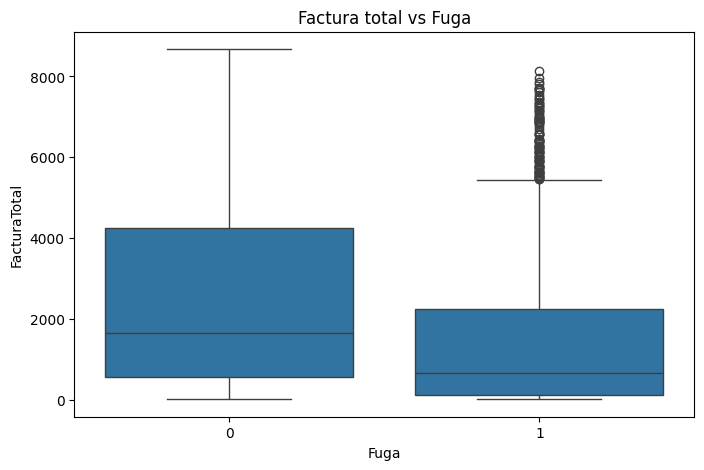

In [25]:
plt.clf()
sns.boxplot(x='Fuga', y='FacturaTotal', data=df_tr)
plt.title('Factura total vs Fuga')
plt.show()

##4) Modelo final

A continuación se muestra el modelo final

In [26]:
# Definición de target y features

y = df_tr['Fuga'].astype(int)
X = df_tr.drop(columns=['Fuga'])

In [27]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1324,
    stratify=y)

print(y_train.value_counts(normalize=True))
print(df['Fuga'].value_counts(normalize=True))
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

Fuga
0    0.734553
1    0.265447
Name: proportion, dtype: float64
Fuga
0    0.734614
1    0.265386
Name: proportion, dtype: float64


In [28]:
form3 = 'Fuga ~ FacturaMes + Contrato + MetodoPago+ Int_serv + Q("Antig.fc.edad2")' #+Servicios_Extra

modelo3 = smf.logit(formula=form3, data=df_train).fit()
print(modelo3.summary())

Optimization terminated successfully.
         Current function value: 0.420203
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                   Fuga   No. Observations:                 5082
Model:                          Logit   Df Residuals:                     5065
Method:                           MLE   Df Model:                           16
Date:                Wed, 20 May 2026   Pseudo R-squ.:                  0.2739
Time:                        10:51:16   Log-Likelihood:                -2135.5
converged:                       True   LL-Null:                       -2940.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -0.1988   

In [29]:
pred_prob3 = modelo3.predict(X_test)
pred_clase3 = (pred_prob3 > 0.5).astype(int)
print("--- Evaluación Modelo 3 ---")
print(classification_report(y_test, pred_clase3))

--- Evaluación Modelo 3 ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       934
           1       0.63      0.51      0.56       337

    accuracy                           0.79      1271
   macro avg       0.73      0.70      0.71      1271
weighted avg       0.78      0.79      0.78      1271



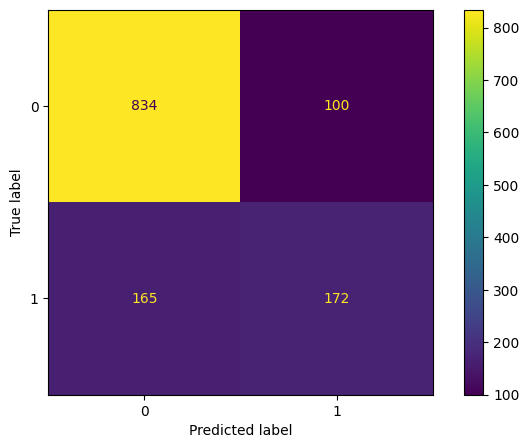

In [30]:
# Definición de umbral
umbral = 0.5

# Predicciones de probabilidad
y_pred = modelo3.predict(df_test)

# Convertir a 0/1 según umbral
y_clas = (y_pred >= umbral).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_clas)

# Mostrar matriz
ConfusionMatrixDisplay(cm).plot()
plt.show()

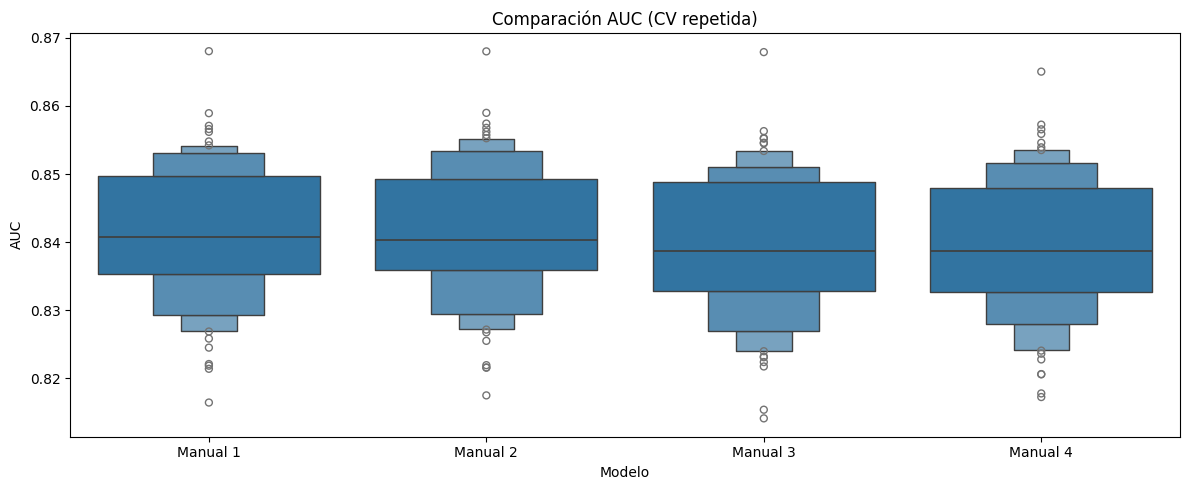

,count,mean,std,min,median,max
Modelo,,,,,,
Manual 1,100,0.841345,0.010022,0.816418,0.840711,0.868049
Manual 2,100,0.841682,0.009943,0.817468,0.840331,0.868022
Manual 3,100,0.839408,0.010269,0.814092,0.838743,0.867915
Manual 4,100,0.839627,0.010146,0.817225,0.838711,0.865046


In [31]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=1324)


def cv_auc_statsmodels(formula, data, cv, y_col="Fuga"):
    import statsmodels.formula.api as smf

    X = data.drop(columns=[y_col])
    y = data[y_col].astype(int).reset_index(drop=True)

    aucs = []
    for tr_idx, te_idx in cv.split(X, y):
        train_df = data.iloc[tr_idx].copy()
        test_df  = data.iloc[te_idx].copy()

        m = smf.logit(formula=formula, data=train_df).fit(disp=0)
        prob = m.predict(test_df)
        aucs.append(roc_auc_score(test_df[y_col].astype(int), prob))

    return np.array(aucs)


form1 = 'Fuga ~ Contrato + Q("Antig.fc.edad2") + Int_serv + MetodoPago + Fact_sinPapel + Servicios_Extra + PersCargo + Conyuge + Mayor65 + FacturaMes'
form2 = 'Fuga ~ Contrato + Q("Antig.fc.edad2") + Int_serv + MetodoPago + Fact_sinPapel + Servicios_Extra + FacturaMes + Mayor65'
form3 = 'Fuga ~ FacturaMes + Contrato + MetodoPago + Int_serv + Q("Antig.fc.edad2")'
form4 = 'Fuga ~ FacturaMes + Contrato + MetodoPago + Int_serv + Q("Antig.fc.edad2") + Servicios_Extra'


data_manual = df_train.copy()
data_manual["Fuga"] = data_manual["Fuga"].astype(int)


aucs_m1 = cv_auc_statsmodels(form1, data_manual, cv, y_col="Fuga")
aucs_m2 = cv_auc_statsmodels(form2, data_manual, cv, y_col="Fuga")
aucs_m3 = cv_auc_statsmodels(form3, data_manual, cv, y_col="Fuga")
aucs_m4 = cv_auc_statsmodels(form4, data_manual, cv, y_col="Fuga")


results = pd.DataFrame({
    "Modelo": (["Manual 1"] * len(aucs_m1) +
               ["Manual 2"] * len(aucs_m2) +
               ["Manual 3"] * len(aucs_m3) +
               ["Manual 4"] * len(aucs_m4)),
    "AUC": np.concatenate([aucs_m1, aucs_m2, aucs_m3, aucs_m4])
})

order = ["Manual 1", "Manual 2", "Manual 3", "Manual 4"]


plt.figure(figsize=(12,5))
sns.boxenplot(
    x="Modelo", y="AUC",
    data=results,
    order=order,
    showfliers=True,
    linewidth=1)

plt.title("Comparación AUC (CV repetida)")
plt.xlabel("Modelo")
plt.ylabel("AUC")
plt.tight_layout()
plt.show()


(results
 .groupby("Modelo")["AUC"]
 .agg(["count","mean","std","min","median","max"])
 .loc[order])

## 5) Justificación de elección del modelo 3
Se ha seleccionado el Modelo 3 como modelo final para el análisis.

La decisión se fundamenta en que presenta un R² comparable al de los demás modelos evaluados, manteniendo un nivel de ajuste similar. Sin embargo, a diferencia de otras especificaciones, el Modelo 3 logra dicho desempeño con un menor número de variables, lo que favorece la parsimonia, la interpretabilidad y la estabilidad del modelo.

Adicionalmente, en términos de capacidad discriminatoria, el Modelo 3 es el que muestra mejor desempeño después del modelo Lasso. No obstante, el modelo Lasso fue descartado debido a que incorpora 23 variables, lo que incrementa la complejidad del modelo y podría generar riesgos asociados a sobreajuste y posibles problemas de multicolinealidad.

En consecuencia, el Modelo 3 representa el mejor equilibrio entre capacidad predictiva, robustez estadística y simplicidad estructural, alineándose con el principio de parsimonia y facilitando su aplicación práctica en un entorno empresarial.

## 6) Interpretación del modelo

In [32]:
# Ajustar modelo 3
modeloF = logit(form3,data=df_train).fit()
print(modeloF.summary())

tr_tst_eval_log(form3,data =df_train)

Optimization terminated successfully.
         Current function value: 0.420203
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                   Fuga   No. Observations:                 5082
Model:                          Logit   Df Residuals:                     5065
Method:                           MLE   Df Model:                           16
Date:                Wed, 20 May 2026   Pseudo R-squ.:                  0.2739
Time:                        10:51:33   Log-Likelihood:                -2135.5
converged:                       True   LL-Null:                       -2940.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -0.1988   

NameError: name 'tr_tst_eval_log' is not defined

In [ ]:
def tr_tst_eval_log(formula, data, test_size=0.2, random_state=1324, threshold=None):
    # Split interno (estratificado)
    train_df, test_df = train_test_split(
        data, test_size=test_size, random_state=random_state,
        stratify=data['Fuga'].astype(int)
    )

    # Ajuste del modelo
    modelo = logit(formula=formula, data=train_df).fit(disp=0)

    # Predicciones y métricas
    probs = modelo.predict(test_df)
    auc_score = roc_auc_score(test_df['Fuga'].astype(int), probs)

    # Selección de umbral óptimo (Youden) si no se proporciona
    if threshold is None:
        fpr, tpr, thr = roc_curve(test_df['Fuga'].astype(int), probs)
        threshold = thr[np.argmax(tpr - fpr)]

    preds = (probs >= threshold).astype(int)

    # Salidas
    print(modelo.summary())
    print(f"\nUmbral usado: {threshold:.4f}    AUC: {auc_score:.4f}\n")
    print(classification_report(test_df['Fuga'].astype(int), preds))

    cm = confusion_matrix(test_df['Fuga'].astype(int), preds)
    ConfusionMatrixDisplay(cm).plot()
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(test_df['Fuga'].astype(int), probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}', color='red')
    plt.plot([0,1],[0,1],'--', color='navy')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    return modelo, threshold, auc_score

# Llamada de evaluación (igual que en la celda previa)
tr_tst_eval_log(form3, data=df_train)

In [ ]:
#Odds ratios
pd.options.display.float_format = '{:.4f}'.format

ORs = np.exp(modeloF.params)

print(ORs[1:len(ORs)])

Contrato[T.One year]                     0.3925
Contrato[T.Two year]                     0.1296
Contrato[T.Desc]                         0.6726
MetodoPago[T.Credit card (automatic)]    0.7539
MetodoPago[T.Electronic check]           1.3890
MetodoPago[T.Mailed check]               0.7608
MetodoPago[T.Desc]                       1.1480
Int_serv[T.Fiber optic]                  2.8224
Int_serv[T.No]                           0.4065
Int_serv[T.Desc]                         2.0286
Q("Antig.fc.edad2")[T.12-30 meses]       0.2783
Q("Antig.fc.edad2")[T.30-55 meses]       0.2110
Q("Antig.fc.edad2")[T.6-12 meses]        0.4661
Q("Antig.fc.edad2")[T.Desconocido]       0.4366
Q("Antig.fc.edad2")[T.Mas de 55 meses]   0.1293
FacturaMes                               1.0027
dtype: float64


## Resultados Principales del Modelo

Se analizan a continuación los principales resultados obtenidos a partir del modelo de regresión logística, expresados mediante Odds Ratios (OR).

1. Tipo de contrato: El tipo de contrato se posiciona como una de las variables con mayor influencia sobre la probabilidad de abandono (churn).

- Contrato de un año (OR = 0,3925): Los clientes con contrato anual presentan aproximadamente un 60,75% menos odds de abandono en comparación con la categoría de referencia.

- Contrato de dos años (OR = 0,1296): Los clientes con contrato bianual muestran un 87% menos odds de abandono, evidenciando un efecto protector significativamente más intenso.

2. Método de pago: El método de pago también muestra asociación estadísticamente relevante con el abandono.

- Electronic check (OR = 1,3890)
Incrementa las odds de abandono en aproximadamente un 39% respecto al método de referencia.

- Otros métodos (por ejemplo, tarjeta automática o cheque enviado por correo) presentan OR menores que 1, lo que indica menor riesgo relativo de abandono.

3. Servicio de internet

- Fibra óptica (OR = 2,8224) Los clientes con servicio de fibra óptica presentan 2,82 veces más odds de abandono, lo que equivale a un incremento aproximado del 182% en el riesgo relativo frente a la categoría de referencia.

4. Antigüedad del cliente: Todas las categorías asociadas a mayor antigüedad presentan OR menores que 1. Existe un efecto protector claro de la antigüedad: a mayor permanencia del cliente en la compañía, menor probabilidad de abandono.

5. Factura mensual
- Factura mensual (OR = 1,0027): Por cada unidad monetaria adicional en la factura mensual, las odds de abandono aumentan en un 0,27%. Si bien el efecto marginal por unidad es reducido, incrementos acumulados en el importe de la factura pueden traducirse en aumentos relevantes en la probabilidad de churn.

## 7) Punto de corte

In [ ]:
# Creamos 4 objetos: predictores para tr y tst y variable objetivo para tr y tst.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5082, 21), (1271, 21), (5082,), (1271,))


Resultados Modelo 3:
[[554 380]
 [ 34 303]]


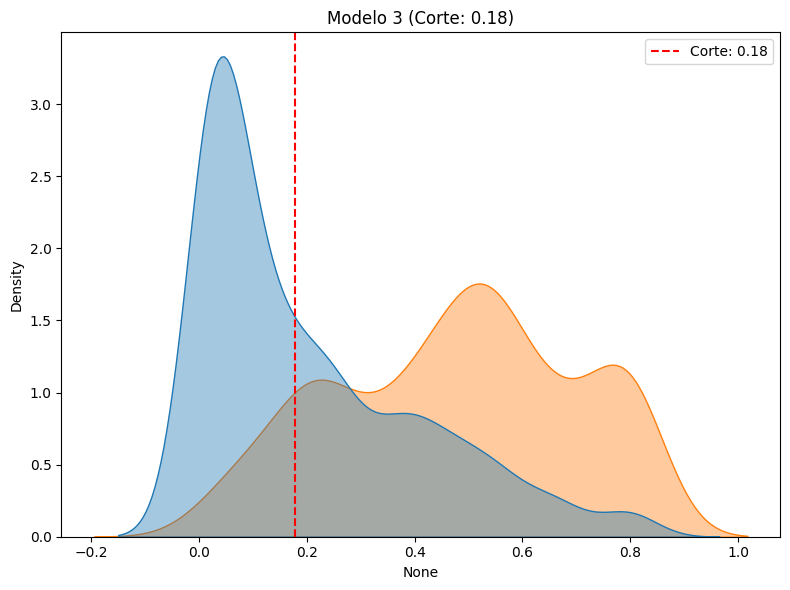

In [ ]:
plt.figure(figsize=(8, 6))

# Entrenar solo el modelo 3
modelo = smf.logit(formula=form3, data=df_train).fit(disp=0)
y_prob = modelo.predict(df_test)

# Curva ROC y punto de corte óptimo
fpr, tpr, thresholds = roc_curve(df_test['Fuga'], y_prob)
optimal_idx = np.argmax(tpr - fpr)
punto_corte = thresholds[optimal_idx]

# Gráfico de densidades
sns.kdeplot(x=y_prob, hue=df_test['Fuga'], fill=True,
            common_norm=False, alpha=0.4)
plt.axvline(x=punto_corte, color='red', linestyle='--',
            label=f'Corte: {punto_corte:.2f}')
plt.title(f"Modelo 3 (Corte: {punto_corte:.2f})")
plt.legend()

# Matriz de confusión
y_pred_clase = (y_prob > punto_corte).astype(int)
matriz = confusion_matrix(df_test['Fuga'], y_pred_clase)

print("\nResultados Modelo 3:")
print(matriz)

plt.tight_layout()
plt.show()

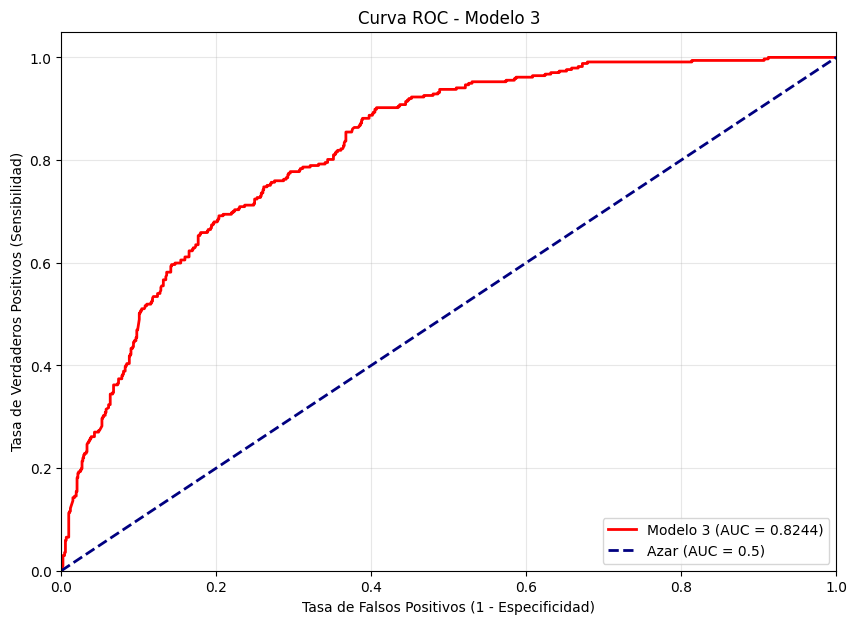

In [ ]:
plt.figure(figsize=(10, 7))

modelo = smf.logit(formula=form3, data=df_train).fit(disp=0)
y_prob = modelo.predict(df_test)

fpr, tpr, _ = roc_curve(df_test['Fuga'], y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='red', lw=2,
         label=f'Modelo 3 (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2,
         linestyle='--', label='Azar (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Modelo 3')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

<Figure size 600x500 with 0 Axes>

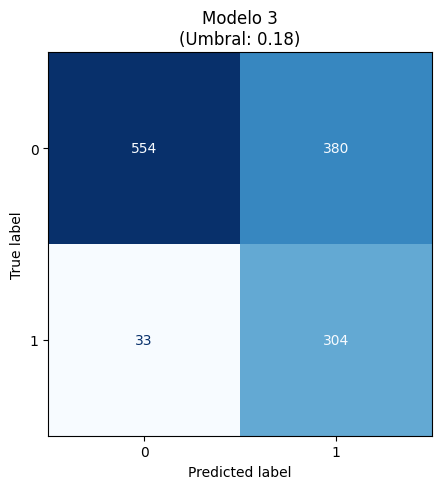

In [ ]:
modelo = smf.logit(formula=form3, data=df_train).fit(disp=0)
y_prob = modelo.predict(df_test)

fpr, tpr, thresholds = roc_curve(df_test['Fuga'], y_prob)
optimal_idx = np.argmax(tpr - fpr)
umbral_optimo = thresholds[optimal_idx]

y_clas = (y_prob >= umbral_optimo).astype(int)
cm = confusion_matrix(df_test['Fuga'], y_clas)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', colorbar=False)

plt.title(f"Modelo 3\n(Umbral: {umbral_optimo:.2f})")
plt.tight_layout()
plt.show()

## Justificación de cambio de punto de corte

El Modelo 3 presenta un AUC de 0,8244, lo que indica una buena capacidad discriminatoria para distinguir entre clientes que abandonan y aquellos que permanecen. Esto implica que el modelo ordena adecuadamente las probabilidades estimadas y permite ajustar estratégicamente el punto de corte según los objetivos del negocio.

El uso de un umbral bajo (0,18) implica una estrategiaorientada a maximizar la detección de clientes con riesgo de abandono.
Sin embargo, esta decisión conlleva un incremento significativo en el número de falsos positivos (380 casos), es decir, clientes que no habrían abandonado pero son clasificados como de riesgo. Esto puede generar un aumento considerable en los costos operativos asociados a campañas de retención.

Desde una perspectiva técnica, sí se justifica evaluar un cambio en el punto de corte, dado que el modelo posee capacidad discriminatoria suficiente y el umbral actual favorece de manera marcada la sensibilidad en detrimento de la especificidad.

##8) Capacidad de predicción en test

In [ ]:
df_caso_real= pd.read_csv('FugaClientes_Test.csv')
df_caso_real.head()

,ID,Genero,Mayor65,Conyuge,PersCargo,Antiguedad,Telf_serv,VariasLineas,Int_serv,Seguridad,CopiaSeguridad,Antivirus_disp,Soporte_tecnico,TV_streaming,Peliculas,Contrato,Fact_sinPapel,MetodoPago,FacturaMes,FacturaTotal
0,4183-MYFRB,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,90.0500,1862.9000
1,8779-QRDMV,Male,1,No,No,1,No,No,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.6500,39.6500
2,1680-VDCWW,Male,0,Yes,No,12,Yes,No,No,No,No,No,No,No,No,One year,No,Bank transfer (automatic),19.8000,202.2500
3,6234-RAAPL,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),99.9000,7251.7000
4,9867-JCZSP,Female,0,Yes,Yes,17,Yes,No,No,No,No,No,No,No,No,One year,No,Mailed check,20.7500,418.2500


In [ ]:
df_caso_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               690 non-null    object 
 1   Genero           690 non-null    object 
 2   Mayor65          690 non-null    int64  
 3   Conyuge          690 non-null    object 
 4   PersCargo        690 non-null    object 
 5   Antiguedad       690 non-null    int64  
 6   Telf_serv        690 non-null    object 
 7   VariasLineas     690 non-null    object 
 8   Int_serv         690 non-null    object 
 9   Seguridad        690 non-null    object 
 10  CopiaSeguridad   690 non-null    object 
 11  Antivirus_disp   690 non-null    object 
 12  Soporte_tecnico  690 non-null    object 
 13  TV_streaming     690 non-null    object 
 14  Peliculas        690 non-null    object 
 15  Contrato         690 non-null    object 
 16  Fact_sinPapel    690 non-null    object 
 17  MetodoPago      

In [ ]:
df_caso_real_processed = df_caso_real.copy()

categoricas_test = df_caso_real_processed.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categoricas_test:
    if col in df_caso_real_processed.columns:
        df_caso_real_processed[col] = df_caso_real_processed[col].astype('category')

        if 'Desc' not in df_caso_real_processed[col].cat.categories:
            df_caso_real_processed[col] = (
                df_caso_real_processed[col]
                .cat.add_categories(['Desc'])
            )

        df_caso_real_processed[col] = (
            df_caso_real_processed[col]
            .fillna('Desc')
        )

if 'ID' in df_caso_real_processed.columns:
    df_caso_real_processed = df_caso_real_processed.drop(columns=['ID'])


service_extra_existing = [col for col in servicio_extra if col in df_caso_real_processed.columns]
df_caso_real_processed['Servicios_Extra'] = (df_caso_real_processed[service_extra_existing] == 'Yes').sum(axis=1)
df_caso_real_processed['Servicios_Extra'] = df_caso_real_processed['Servicios_Extra'].astype('category')


df_caso_real_processed['Antig.fc.edad2'] = df_caso_real_processed['Antiguedad'].apply(recode)
df_caso_real_processed['Antig.fc.edad2'] = df_caso_real_processed['Antig.fc.edad2'].astype('category')


median_facturames_train = df_train['FacturaMes'].median()
median_facturatotal_train = df_train['FacturaTotal'].median()


df_caso_real_processed['FacturaMes'] = df_caso_real_processed['FacturaMes'].fillna(median_facturames_train)


df_caso_real_processed['FacturaTotal'] = df_caso_real_processed['FacturaTotal'].fillna(median_facturatotal_train)


print("\ndf_caso_real_processed info:")
df_caso_real_processed.info()
print("\ndf_caso_real_processed head:")
df_caso_real_processed.head()


df_caso_real_processed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Genero           690 non-null    category
 1   Mayor65          690 non-null    int64   
 2   Conyuge          690 non-null    category
 3   PersCargo        690 non-null    category
 4   Antiguedad       690 non-null    int64   
 5   Telf_serv        690 non-null    category
 6   VariasLineas     690 non-null    category
 7   Int_serv         690 non-null    category
 8   Seguridad        690 non-null    category
 9   CopiaSeguridad   690 non-null    category
 10  Antivirus_disp   690 non-null    category
 11  Soporte_tecnico  690 non-null    category
 12  TV_streaming     690 non-null    category
 13  Peliculas        690 non-null    category
 14  Contrato         690 non-null    category
 15  Fact_sinPapel    690 non-null    category
 16  MetodoPago    

,Genero,Mayor65,Conyuge,PersCargo,Antiguedad,Telf_serv,VariasLineas,Int_serv,Seguridad,CopiaSeguridad,Antivirus_disp,Soporte_tecnico,TV_streaming,Peliculas,Contrato,Fact_sinPapel,MetodoPago,FacturaMes,FacturaTotal,Servicios_Extra,Antig.fc.edad2
0,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,90.0500,1862.9000,4,12-30 meses
1,Male,1,No,No,1,No,No,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.6500,39.6500,2,0-6 meses
2,Male,0,Yes,No,12,Yes,No,No,No,No,No,No,No,No,One year,No,Bank transfer (automatic),19.8000,202.2500,1,6-12 meses
3,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),99.9000,7251.7000,6,Mas de 55 meses
4,Female,0,Yes,Yes,17,Yes,No,No,No,No,No,No,No,No,One year,No,Mailed check,20.7500,418.2500,1,12-30 meses


In [ ]:
df_caso_real_processed['FacturaMes']=df_caso_real_processed['FacturaMes'].astype(float)

In [ ]:
df_caso_real_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Genero           690 non-null    category
 1   Mayor65          690 non-null    int64   
 2   Conyuge          690 non-null    category
 3   PersCargo        690 non-null    category
 4   Antiguedad       690 non-null    int64   
 5   Telf_serv        690 non-null    category
 6   VariasLineas     690 non-null    category
 7   Int_serv         690 non-null    category
 8   Seguridad        690 non-null    category
 9   CopiaSeguridad   690 non-null    category
 10  Antivirus_disp   690 non-null    category
 11  Soporte_tecnico  690 non-null    category
 12  TV_streaming     690 non-null    category
 13  Peliculas        690 non-null    category
 14  Contrato         690 non-null    category
 15  Fact_sinPapel    690 non-null    category
 16  MetodoPago       690 non-null    category
 1

In [ ]:
print(df_caso_real_processed.columns)

niveles_antiguedad = ['0-6 meses', '12-30 meses', '30-55 meses', '6-12 meses', 'Desconocido', 'Mas de 55 meses']

if 'Antig.fc.edad2' in df_caso_real_processed.columns:
    df_caso_real_processed['Antig.fc.edad2'] = pd.Categorical(
        df_caso_real_processed['Antig.fc.edad2'],
        categories=niveles_antiguedad
    )

variables_modelo3 = ['FacturaMes', 'Contrato', 'MetodoPago', 'Int_serv', 'Antig.fc.edad2']
df_final_pred = df_caso_real_processed.dropna(subset=variables_modelo3)

Index(['Genero', 'Mayor65', 'Conyuge', 'PersCargo', 'Antiguedad', 'Telf_serv',
       'VariasLineas', 'Int_serv', 'Seguridad', 'CopiaSeguridad',
       'Antivirus_disp', 'Soporte_tecnico', 'TV_streaming', 'Peliculas',
       'Contrato', 'Fact_sinPapel', 'MetodoPago', 'FacturaMes', 'FacturaTotal',
       'Servicios_Extra', 'Antig.fc.edad2'],
      dtype='object')


In [ ]:
col_problema = 'Antig.fc.edad2'


niveles_esperados = ['0-6 meses', '12-30 meses', '30-55 meses', '6-12 meses', 'Desconocido', 'Mas de 55 meses']

df_caso_real_processed[col_problema] = pd.Categorical(
    df_caso_real_processed[col_problema],
    categories=niveles_esperados
)

df_caso_real_processed = df_caso_real_processed.dropna(subset=['FacturaMes', 'Contrato', 'MetodoPago', 'Int_serv', col_problema])

In [ ]:
modelo_final = smf.logit(formula=form3, data=df_train).fit(disp=0)

y_prob_nuevo = modelo_final.predict(df_caso_real_processed)

umbral_optimo = 0.1782
y_pred_nuevo = (y_prob_nuevo >= umbral_optimo).astype(int)

resultados = pd.DataFrame({
    'Probabilidad_Fuga': y_prob_nuevo,
    'Prediccion_Fuga': y_pred_nuevo
})


resultados['ID_Cliente'] = df_caso_real['ID']

print(resultados.head())

   Probabilidad_Fuga  Prediccion_Fuga  ID_Cliente
0             0.5326                1  4183-MYFRB
1             0.5588                1  8779-QRDMV
2             0.0604                0  1680-VDCWW
3             0.0483                0  6234-RAAPL
4             0.0285                0  9867-JCZSP


In [ ]:
resultados.set_index('ID_Cliente', inplace=True)
resultados.head()

,Probabilidad_Fuga,Prediccion_Fuga
ID_Cliente,,
4183-MYFRB,0.5326,1
8779-QRDMV,0.5588,1
1680-VDCWW,0.0604,0
6234-RAAPL,0.0483,0
9867-JCZSP,0.0285,0


## 9) Generar el CSV

In [ ]:
# Generar el archivo CSV
#resultados.to_csv('FugaPredict_ONU.csv', index=True, sep=',', encoding='utf-8')
#print("Archivo 'FugaPredict_ONU.csv' creado con éxito.")

Archivo 'FugaPredict_ONU.csv' creado con éxito.
